# Player Discipline

## Research Question

Do defenders and midfielders differ significantly in their average number of yellow cards during the FIFA World Cup 2026?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
player_file = r"C:\Users\Sujan\Desktop\Fifa-World-Cup-2026\data\raw\fbref_player_stats_2026_raw.csv"

In [4]:
players = pd.read_csv(player_file, header=1)

In [5]:
players.shape

(1039, 26)

In [6]:
players[['Player', 'Pos', 'Squad', 'MP', 'Min', 'CrdY']].head(10)

,Player,Pos,Squad,MP,Min,CrdY
0,Brenden Aaronson,MF,us USA,1,76,0
1,Thelo Aasgaard,MF,no Norway,1,90,0
2,Hamza Abdelkarim,FW,eg Egypt,4,60,0
3,Hossam Abdelmaguid,DF,eg Egypt,2,59,0
4,Mohamed Abdelmonem,DF,eg Egypt,2,14,0
5,Ali Abdi,DF,tn Tunisia,3,269,0
6,Saud Abdulhamid,DF,sa Saudi Arabia,3,269,1
7,Abdulla Abdullaev,DF,uz Uzbekistan,2,180,0
8,Yusuf Abdurisag,FW,qa Qatar,2,98,0
9,Husam Abu Dahab,DF,jo Jordan,2,178,1


In [7]:
players['Pos'].value_counts()

Pos
MF      344
DF      306
FW      159
FWMF     77
GK       62
DFMF     40
MFFW     36
MFDF     12
DFFW      3
Name: count, dtype: int64

In [8]:
players[['Player', 'Pos', 'Squad', 'MP', 'Min', 'CrdY']].isnull().sum()

Player    0
Pos       0
Squad     0
MP        0
Min       0
CrdY      0
dtype: int64

In [9]:
discipline = players[
    ['Player', 'Pos', 'Squad', 'MP', 'Min', 'CrdY']
].copy()

print("Discipline dataset created.")
print("Rows:", len(discipline))

Discipline dataset created.
Rows: 1039


In [10]:
discipline = discipline[
    discipline['Pos'].isin(['DF', 'MF'])
].copy()

print("Eligible players:", len(discipline))
print("\nPosition counts:")
print(discipline['Pos'].value_counts())

Eligible players: 650

Position counts:
Pos
MF    344
DF    306
Name: count, dtype: int64


In [11]:
discipline['Position_Group'] = discipline['Pos'].map({
    'DF': 'Defender',
    'MF': 'Midfielder'
})

In [12]:
discipline[['Player', 'Pos', 'Position_Group', 'CrdY']].head(10)

,Player,Pos,Position_Group,CrdY
0,Brenden Aaronson,MF,Midfielder,0
1,Thelo Aasgaard,MF,Midfielder,0
3,Hossam Abdelmaguid,DF,Defender,0
4,Mohamed Abdelmonem,DF,Defender,0
5,Ali Abdi,DF,Defender,0
6,Saud Abdulhamid,DF,Defender,1
7,Abdulla Abdullaev,DF,Defender,0
9,Husam Abu Dahab,DF,Defender,1
10,Mohammad Abu Hasheesh,DF,Defender,0
11,Mohannad Abu Taha,DF,Defender,1


In [13]:
# Separate the two position groups

defenders = discipline[
    discipline['Position_Group'] == 'Defender'
].copy()

midfielders = discipline[
    discipline['Position_Group'] == 'Midfielder'
].copy()


# Take a reproducible random sample from each group

defender_sample = defenders.sample(
    n=150,
    random_state=42
)

midfielder_sample = midfielders.sample(
    n=150,
    random_state=42
)


# Combine both samples

discipline_sample = pd.concat(
    [defender_sample, midfielder_sample],
    ignore_index=True
)


print("Defender sample:", len(defender_sample))
print("Midfielder sample:", len(midfielder_sample))
print("Total sample:", len(discipline_sample))

Defender sample: 150
Midfielder sample: 150
Total sample: 300


In [14]:
discipline_sample['Position_Group'].value_counts()

Position_Group
Defender      150
Midfielder    150
Name: count, dtype: int64

In [15]:
discipline_sample[
    ['Player', 'Pos', 'Position_Group', 'CrdY']
].head(10)

,Player,Pos,Position_Group,CrdY
0,Brandon Mechele,DF,Defender,1
1,Ladislav Krejčí,DF,Defender,1
2,Grant Hanley,DF,Defender,0
3,Abdallah Nasib,DF,Defender,0
4,Pau Cubarsí,DF,Defender,1
5,Ricardo Adé,DF,Defender,0
6,Jack Hendry,DF,Defender,0
7,Ali Lajami,DF,Defender,0
8,Gabriel Magalhães,DF,Defender,0
9,Rafik Belghali,DF,Defender,0


In [16]:
discipline_sample['CrdY'].describe()

count    300.000000
mean       0.343333
std        0.577263
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        3.000000
Name: CrdY, dtype: float64

In [17]:
# Descriptive statistics for each position group

discipline_summary = discipline_sample.groupby(
    'Position_Group'
)['CrdY'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Standard_Deviation='std',
    Minimum='min',
    Maximum='max'
)

discipline_summary

,Count,Mean,Median,Standard_Deviation,Minimum,Maximum
Position_Group,,,,,,
Defender,150,0.346667,0.0,0.579130,0,3
Midfielder,150,0.340000,0.0,0.577312,0,2


In [18]:
# Yellow-card distribution by position group

yellow_card_distribution = pd.crosstab(
    discipline_sample['Position_Group'],
    discipline_sample['CrdY']
)

yellow_card_distribution

CrdY,0,1,2,3
Position_Group,,,,
Defender,105,39,5,1
Midfielder,107,35,8,0


In [19]:
# Percentage of players receiving at least one yellow card

yellow_card_rate = discipline_sample.groupby(
    'Position_Group'
)['CrdY'].apply(
    lambda x: (x > 0).mean() * 100
)

yellow_card_rate

Position_Group
Defender      30.000000
Midfielder    28.666667
Name: CrdY, dtype: float64

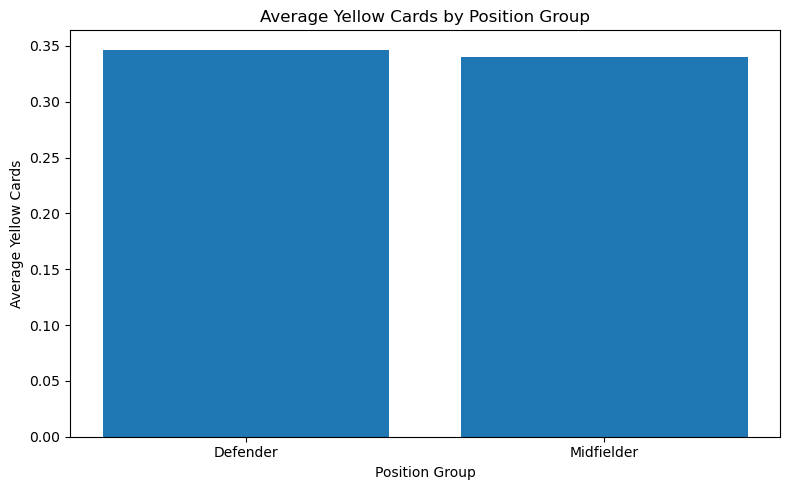

In [20]:
# Compare average yellow cards between defenders and midfielders

group_means = discipline_sample.groupby(
    'Position_Group'
)['CrdY'].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    group_means.index,
    group_means.values
)

plt.title('Average Yellow Cards by Position Group')
plt.xlabel('Position Group')
plt.ylabel('Average Yellow Cards')

plt.tight_layout()
plt.show()